In [1]:

from spm_agent.states.image_analysis_state import AnalysisState

from langgraph.graph import StateGraph, START, END

In [2]:
from spm_agent.nodes.agentic_segmentation_node import agentic_segmentation_node
from spm_agent.nodes.channel_recommendation_node import channel_recommendation_node
from spm_agent.nodes.set_experiment_tasks_node import make_experiment_tasks_node
from spm_agent.nodes.importance_map_node import importance_map_node
from spm_agent.nodes.build_loop_node import build_loop_node
from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.nodes.route_by_meas_kind_node import route_by_kind
from spm_agent.nodes.loop_params_node import loop_params_node
from spm_agent.nodes.loop_review_node import loop_review_node

EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    "Study wall-mediated switching"
]

# --- image subgraph: the whole existing chain, compiled separately ---
img = StateGraph(AnalysisState)
img.add_node("channel_recommendation", channel_recommendation_node)
img.add_node("segmentation", agentic_segmentation_node)
img.add_node("set_tasks", make_experiment_tasks_node(EXPERIMENT_TASKS)) # type: ignore
img.add_node("importance_map", importance_map_node)
img.add_edge(START, "channel_recommendation")
img.add_edge("channel_recommendation", "segmentation")
img.add_edge("segmentation", "set_tasks")
img.add_edge("set_tasks", "importance_map")
img.add_edge("importance_map", END)
image_graph = img.compile()

# --- loop subgraph, same idea ---
lp = StateGraph(AnalysisState)
lp.add_node("build_loop", build_loop_node)
lp.add_node("loop_params", loop_params_node)
lp.add_node("loop_review", loop_review_node)
# later: lp.add_node("loop_params", ...), lp.add_node("loop_review", ...)
lp.add_edge(START, "build_loop")
lp.add_edge("build_loop", "loop_params")
lp.add_edge("loop_params", "loop_review")
lp.add_edge("loop_review", END)
loop_graph = lp.compile()

# --- parent analysis graph ---
builder = StateGraph(AnalysisState)
builder.add_node("readfile", readfile_node)
builder.add_node("image_analysis", image_graph)     # compiled graph as node
builder.add_node("loop_analysis", loop_graph)

builder.add_edge(START, "readfile")
builder.add_conditional_edges("readfile", route_by_kind,
                              {"image": "image_analysis",
                               "loop": "loop_analysis",
                               "spectrum": END})


builder.add_edge("image_analysis", END)
builder.add_edge("loop_analysis", END)

In [3]:
im_graph = builder.compile()

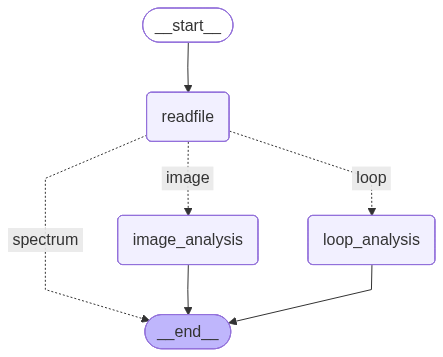

In [4]:
im_graph

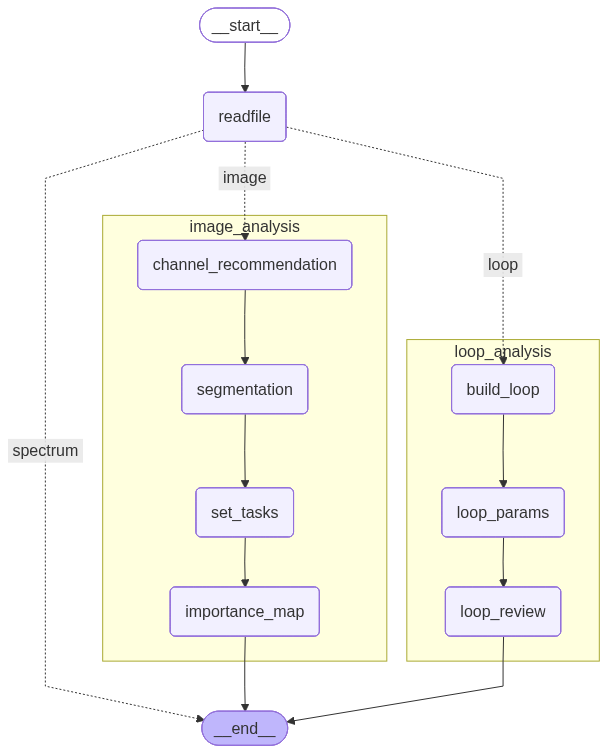

In [5]:
from IPython.display import Image
Image(im_graph.get_graph(xray=True).draw_mermaid_png())

In [6]:
res = await im_graph.ainvoke({"file_path": r"/Users/borisslautin/Downloads/PLZT/PLZT_0005.ibw"})

loop


In [7]:
from pprint import pprint

In [16]:
res['loop_review'].issues

['Noisy/ragged rising branch at positive bias (>+3 V), likely due to tip-sample instability or electrostatic ringing at high fields',
 'Phase offset of ~40° is moderately large, suggesting incomplete quadrature correction; quadrature residual (0.066) is acceptable but non-negligible',
 'Slight asymmetry in remnant amplitudes: remnant_rising (~+225 pm) vs remnant_falling (~-331 pm) indicates the two polarization states are not equally stable',
 'Saturation values are asymmetric (sat_at_vplus ≈ -324 pm vs sat_at_vminus ≈ +238 pm), hinting at a non-zero response offset (-43 pm) and possible incomplete positive-bias saturation']

In [17]:
dir(res['loop_review'])

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__class_vars__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__fields__',
 '__fields_set__',
 '__format__',
 '__ge__',
 '__get_pydantic_core_schema__',
 '__get_pydantic_json_schema__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__pretty__',
 '__private_attributes__',
 '__pydantic_complete__',
 '__pydantic_computed_fields__',
 '__pydantic_core_schema__',
 '__pydantic_custom_init__',
 '__pydantic_decorators__',
 '__pydantic_extra__',
 '__pydantic_extra_info__',
 '__pydantic_fields__',
 '__pydantic_fields_set__',
 '__pydantic_generic_metadata__',
 '__pydantic_init_subclass__',
 '__pydantic_on_complete__',
 '__pydantic_parent_namespace__',
 '__pydantic_post_init__',
 '__pydantic_private__',
 '__pydantic_root_model__

In [20]:
pprint(res['loop_review'].dict())

{'confidence': 0.88,
 'interpretation': 'The off-field loop shows a well-defined, clockwise '
                   'hysteresis with clear coercive voltages (Vc+ ≈ +2.99 V, '
                   'Vc− ≈ −2.74 V) and large loop height (~556 pm), consistent '
                   'with genuine ferroelectric polarization switching rather '
                   'than a purely electrostatic artifact. The small positive '
                   'imprint (+0.13 V) indicates a very slight built-in '
                   'internal bias favoring the negative-polarization state, '
                   'likely from surface charge or asymmetric electrode '
                   'screening. The loop width (~5.73 V) is moderate and the '
                   'area per cycle (3.68×10⁻⁹ m·V) reflects good switching '
                   'energy. The remnant asymmetry and noisy high-field rising '
                   'branch suggest some disorder or tip instability at large '
                   'positive voltages, but the over

/var/folders/bc/5_vf1n1s61df21xwx7889ld00000gn/T/ipykernel_96326/1644639498.py:1: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  pprint(res['loop_review'].dict())


In [10]:
ar = load_array("/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/Amp.npy")

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline 

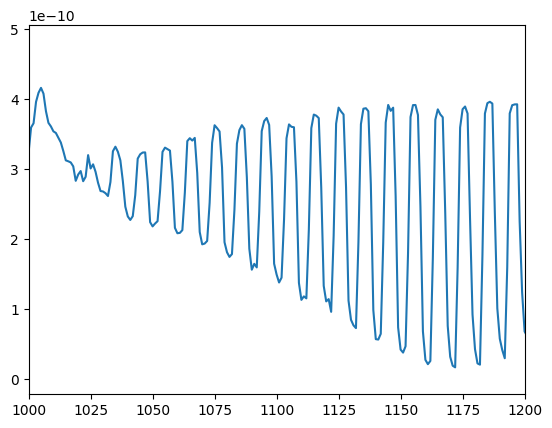

In [12]:
plt.plot(ar)
plt.xlim(1000, 1200)
plt.show()